In [42]:
# Install needed libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Compile transcriptome tsvs into one pandas dataframe

# Read the files
df1 = pd.read_csv('Data/TCGA_Transcriptome/TCGA-KICH.transcriptome.tsv', sep='\t')
df2 = pd.read_csv('Data/TCGA_Transcriptome/TCGA-KIRC.transcriptome.tsv', sep='\t')
df3 = pd.read_csv('Data/TCGA_Transcriptome/TCGA-KIRP.transcriptome.tsv', sep='\t')

# Get the name of the first (gene name) column
gene_col = df1.columns[0]

# Set gene name as index for all three
df1 = df1.set_index(gene_col)
df2 = df2.set_index(gene_col)
df3 = df3.set_index(gene_col)

# Concatenate along columns (axis=1)
combined_df = pd.concat([df1, df2, df3], axis=1)

# Reset index to make gene names a column again
combined_df1 = combined_df.reset_index()

print(f"\nTranscriptome combined dataframe shape: {combined_df1.shape}")


Transcriptome combined dataframe shape: (60660, 1025)


/tmp/ipykernel_3335573/2937472606.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df1 = combined_df.reset_index()


In [6]:
# Combine clinical data tsvs into one pandas dataframe and drop all unneeded columns

# Read the files
df1 = pd.read_csv('Data/TCGA_Clinical/TCGA-KICH.clinical.tsv', sep='\t')
df2 = pd.read_csv('Data/TCGA_Clinical/TCGA-KIRC.clinical.tsv', sep='\t')
df3 = pd.read_csv('Data/TCGA_Clinical/TCGA-KIRP.clinical.tsv', sep='\t')

# Assign a list of columns we will keep
columns_to_keep = ['sample', 'primary_diagnosis.diagnoses']

# Create new dataframes that ONLY have the columns we want
df1a = df1[columns_to_keep]
df2a = df2[columns_to_keep]
df3a = df3[columns_to_keep]

# Concatenate along rows (axis=0)
combined_df2 = pd.concat([df1a, df2a, df3a], axis=0)

print(f"\nClinical combined dataframe shape: {combined_df2.shape}")


Clinical combined dataframe shape: (1407, 2)


In [7]:
# Make sure only samples present in BOTH dataframes are included
# Extract names from each dataframe
names_in_columns = set(combined_df1.columns)  # names from df1's column headers
first_col = combined_df2.columns[0]           # get the name of df2's first column
names_in_rows = set(combined_df2[first_col])  # names from df2's first column

# Find names present in BOTH
common_names = names_in_columns & names_in_rows

print(f"Names in df1 (columns): {len(names_in_columns)}")
print(f"Names in df2 (rows):    {len(names_in_rows)}")
print(f"Names in common:        {len(common_names)}")

# Filter df1: keep only columns whose header is a common name
# (preserve any non-name columns like a gene/ID column if needed)
non_name_cols = [combined_df1.columns[0]]  # e.g., keep the first column (gene names, etc.)
name_cols_to_keep = [c for c in combined_df1.columns if c in common_names]
transcriptome = combined_df1[non_name_cols + name_cols_to_keep]
# Transpose df1: make the Subject ID the row names instead, to match df2
transcriptome = transcriptome.set_index(transcriptome.columns[0]) # set Ensembl_ID as index
transcriptome = transcriptome.T # samples as rows, genes as columns
transcriptome.index.name = 'sample' # name the index

# Filter df2: keep only rows where the first column value is a common name
clinical = combined_df2[combined_df2[first_col].isin(common_names)]
clinical.columns = ['sample', 'primary_diagnosis']
clinical = clinical.set_index('sample')

print(f"\nTranscriptome dataframe filtered shape: {transcriptome.shape}")
print(f"Clinical dataframe filtered shape: {clinical.shape}")

transcriptome.to_csv(r'Data/TCGA_Transcriptome/filtered_transcriptome.tsv', sep='\t', index=False)
clinical.to_csv(r'Data/TCGA_Clinical/filtered_clinical.tsv', sep='\t', index=False)

Names in df1 (columns): 1025
Names in df2 (rows):    1407
Names in common:        1024

Transcriptome dataframe filtered shape: (1024, 60660)
Clinical dataframe filtered shape: (1024, 1)


In [8]:
# Variance filtering: only include the genes with the top 5000 variances.
gene_variances = transcriptome.var(axis=0) # variance per gene
top_genes = gene_variances.nlargest(5000).index # top 5000 gene IDs
transcriptome = transcriptome[top_genes] # shape: (1025, 5000)

print(f"X shape after variance filtering: {transcriptome.shape}")

X shape after variance filtering: (1024, 5000)


In [9]:
# Convert target labels to numbers
# Combine labels for all Renal Cell Carcinoma types
clinical['primary_diagnosis'] = clinical['primary_diagnosis'].replace({
    'Renal cell carcinoma, NOS': 'Renal cell carcinoma, NOS or chromophobe type',
    'Renal cell carcinoma, chromophobe type': 'Renal cell carcinoma, NOS or chromophobe type'})

le = LabelEncoder()
clinical['label'] = le.fit_transform(clinical['primary_diagnosis'])

print(f"\nClass mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")


Class mapping:
  0: Clear cell adenocarcinoma, NOS
  1: Papillary adenocarcinoma, NOS
  2: Renal cell carcinoma, NOS or chromophobe type


In [38]:
# Align x and y, then split
# Align on shared samples (same order)
common_samples = transcriptome.index.intersection(clinical.index)
X = transcriptome.loc[common_samples]
y = clinical.loc[common_samples, 'label']

print(f"\nFinal X shape: {X.shape}")
print(f"Final y shape: {y.shape}")
print(f"\nClass distribution:\n{y.value_counts().sort_index()}")

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves subtype proportions in both splits
)

# Linearly scales the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_test_scaled = scaler.transform(X_test)         # transform test using train's parameters

# PCA scales the data
pca = PCA(random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)   # fit ONLY on train
X_test_pca  = pca.transform(X_test_scaled)         # transform test using train's PCA

print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")


Final X shape: (1024, 5000)
Final y shape: (1024,)

Class distribution:
label
0    596
1    323
2    105
Name: count, dtype: int64

X_train: (819, 5000), X_test: (205, 5000)
y_train: (819,), y_test: (205,)


In [ ]:
# Model 1: Logistic Regression with L1 regularization

=== SVM (Linear Kernel) ===
Accuracy: 0.9220
                                               precision    recall  f1-score   support

               Clear cell adenocarcinoma, NOS       0.97      0.95      0.96       119
                Papillary adenocarcinoma, NOS       0.91      0.91      0.91        65
Renal cell carcinoma, NOS or chromophobe type       0.71      0.81      0.76        21

                                     accuracy                           0.92       205
                                    macro avg       0.86      0.89      0.87       205
                                 weighted avg       0.93      0.92      0.92       205



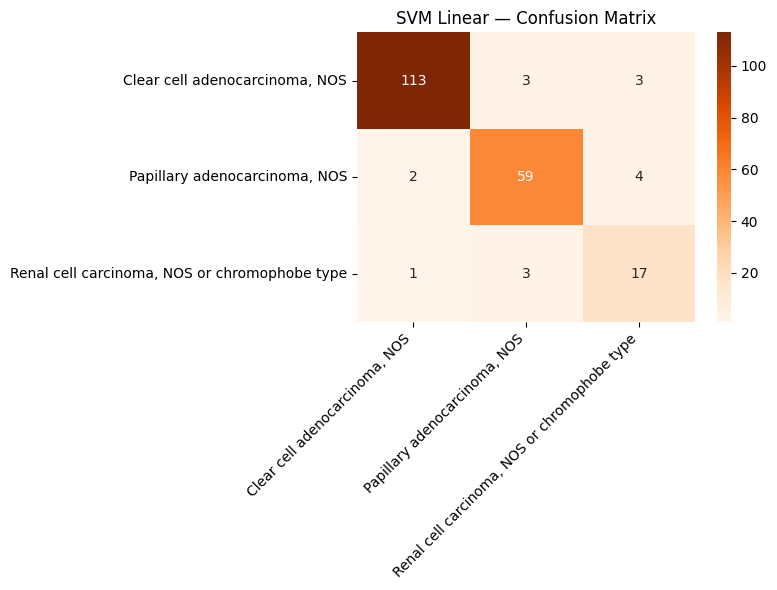

In [29]:
# Model 2: SVM with linear kernel
# ── SVM: LINEAR KERNEL ───────────────────────────────────────────────────────
svm_linear = SVC(
    kernel='linear',
    C=1.0,
    class_weight='balanced',
    random_state=42,
)

svm_linear.fit(X_train_scaled, y_train)
y_pred_svm_linear = svm_linear.predict(X_test_scaled)

# ── METRICS ──────────────────────────────────────────────────────────────────
print("=== SVM (Linear Kernel) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_linear):.4f}")
print(classification_report(y_test, y_pred_svm_linear, target_names=le.classes_))

cm2 = confusion_matrix(y_test, y_pred_svm_linear)
plt.figure(figsize=(8,6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('SVM Linear — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Model 3: Random Forest

In [ ]:
# Model 4: XG Boost

/home/epirzada/miniforge3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


=== Logistic Regression (Elastic Net) ===
Accuracy: 0.9268
                                               precision    recall  f1-score   support

               Clear cell adenocarcinoma, NOS       0.99      0.92      0.96       119
                Papillary adenocarcinoma, NOS       0.92      0.92      0.92        65
Renal cell carcinoma, NOS or chromophobe type       0.69      0.95      0.80        21

                                     accuracy                           0.93       205
                                    macro avg       0.87      0.93      0.89       205
                                 weighted avg       0.94      0.93      0.93       205



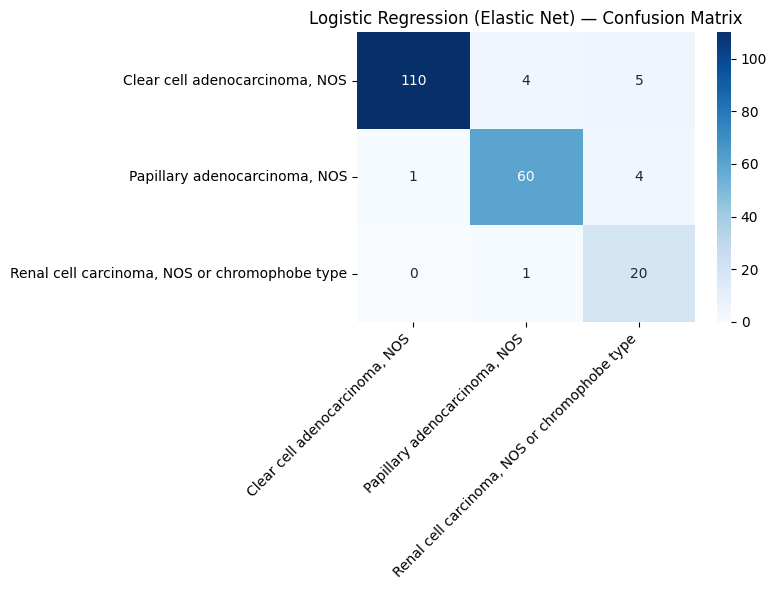

In [43]:
# Model 5: Logistic Regression with Elastic Net Regularization
# ── LOGISTIC REGRESSION: ELASTICNET ──────────────────────────────────────────
lr_en = LogisticRegression(
    solver='saga',
    l1_ratio=0.5,
    C=1.0,
    class_weight='balanced',
    random_state=42,
)

lr_en.fit(X_train_scaled, y_train)
y_pred_lr_en = lr_en.predict(X_test_scaled)

# ── METRICS ──────────────────────────────────────────────────────────────────
print("=== Logistic Regression (Elastic Net) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_en):.4f}")
print(classification_report(y_test, y_pred_lr_en, target_names=le.classes_))

cm5 = confusion_matrix(y_test, y_pred_lr_en)
plt.figure(figsize=(8,6))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression (Elastic Net) — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

=== LightGBM ===
Accuracy:  0.9366
                                               precision    recall  f1-score   support

               Clear cell adenocarcinoma, NOS       0.96      0.97      0.97       119
                Papillary adenocarcinoma, NOS       0.92      0.92      0.92        65
Renal cell carcinoma, NOS or chromophobe type       0.84      0.76      0.80        21

                                     accuracy                           0.94       205
                                    macro avg       0.91      0.89      0.90       205
                                 weighted avg       0.94      0.94      0.94       205



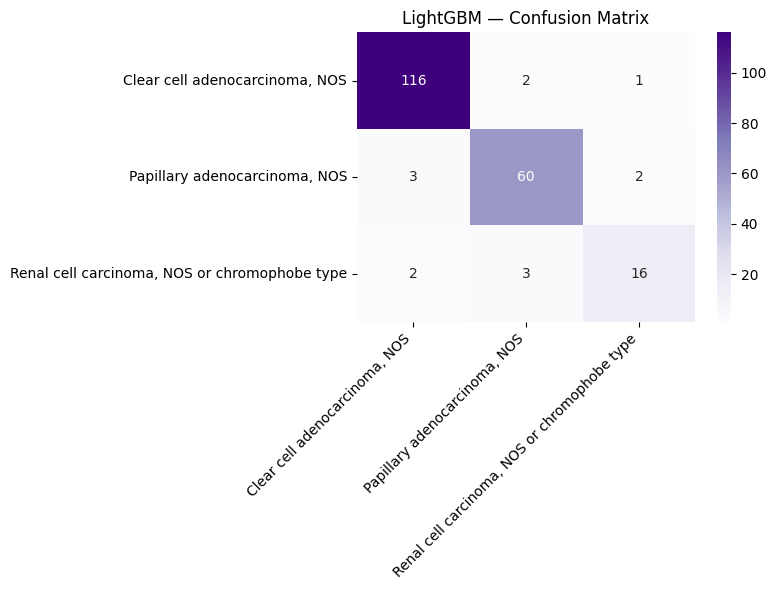

In [45]:
# Model 6: Light GBM
# ── LIGHTGBM ────────────────────────────────────────────────────────
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)

lgbm.fit(X_train, y_train, eval_set=[(X_test, y_test)])
y_pred_lgbm = lgbm.predict(X_test)

# ── METRICS ──────────────────────────────────────────────────────────────────
print("=== LightGBM ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(classification_report(y_test, y_pred_lgbm, target_names=le.classes_))

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('LightGBM — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

=== Logistic Regression (Elastic Net) ===
Accuracy: 0.8927
                                               precision    recall  f1-score   support

               Clear cell adenocarcinoma, NOS       0.96      0.92      0.94       119
                Papillary adenocarcinoma, NOS       0.92      0.86      0.89        65
Renal cell carcinoma, NOS or chromophobe type       0.60      0.86      0.71        21

                                     accuracy                           0.89       205
                                    macro avg       0.82      0.88      0.84       205
                                 weighted avg       0.91      0.89      0.90       205



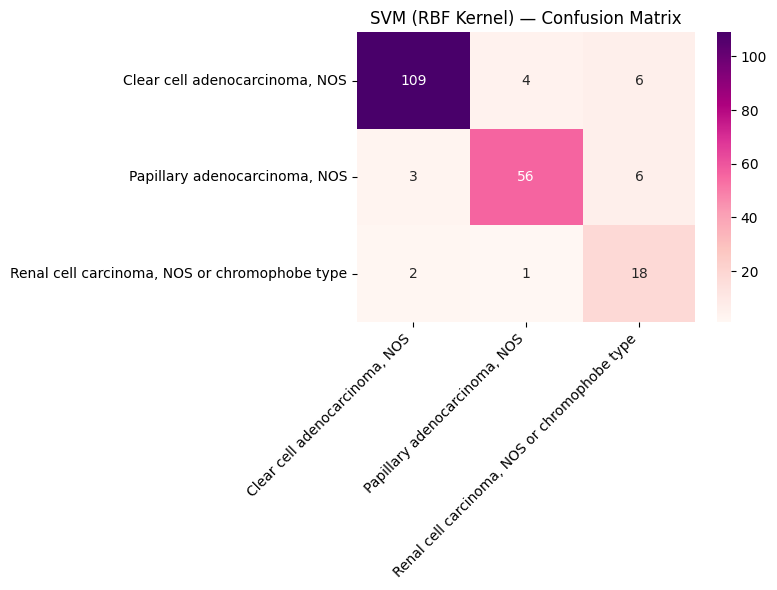

In [39]:
# Model 7: SVM with RBM kernel
# ── SVM (RBF KERNEL) ────────────────────────────────────────────────
svm_rbf = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)

svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

# ── METRICS ──────────────────────────────────────────────────────────────────
print("=== Logistic Regression (Elastic Net) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}")
print(classification_report(y_test, y_pred_rbf, target_names=le.classes_))

cm_rbf = confusion_matrix(y_test, y_pred_rbf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='RdPu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('SVM (RBF Kernel) — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

=== MLP Neural Network (after PCA) ===
Accuracy: 0.8927
                                               precision    recall  f1-score   support

               Clear cell adenocarcinoma, NOS       0.94      0.97      0.95       119
                Papillary adenocarcinoma, NOS       0.91      0.91      0.91        65
Renal cell carcinoma, NOS or chromophobe type       0.89      0.76      0.82        21

                                     accuracy                           0.93       205
                                    macro avg       0.91      0.88      0.89       205
                                 weighted avg       0.93      0.93      0.93       205



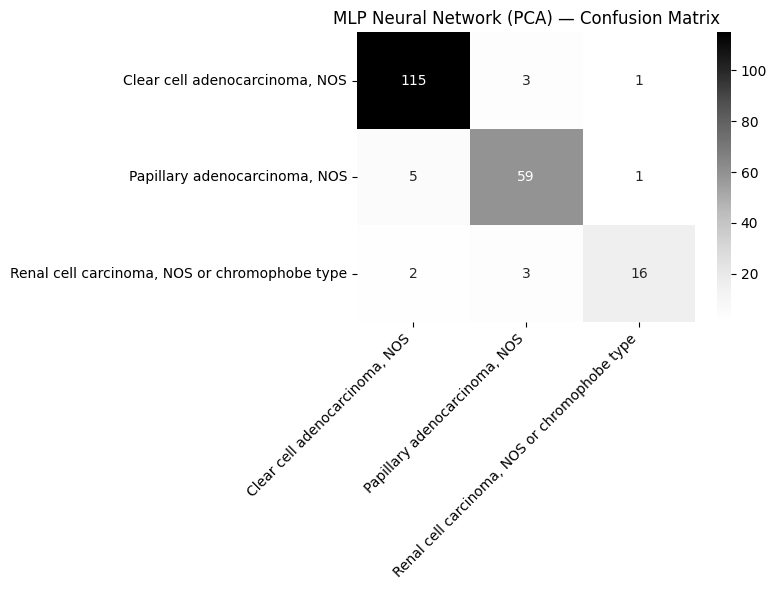

In [41]:
# Model 8: MLP after PCA dimensionality reduction
# ── Multi-Level Perceptron ─────────────────────────────────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # two hidden layers
    activation='relu',
    solver='adam',
    alpha=0.001,                    # L2 regularization
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_pca, y_train)
y_pred_mlp = mlp.predict(X_test_pca)

# ── METRICS ──────────────────────────────────────────────────────────────────
print("=== MLP Neural Network (after PCA) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}")
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))


cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greys',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('MLP Neural Network (PCA) — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()